# RFDC PC Receiver -- Row Program Ethernet-overlap protocol

Receives asynchronous SHOT payloads and explicit DROP records. Saves every received capture as raw int16 RX_A/RX_B files plus a JSONL manifest; dropped scheduled runs are logged in the same manifest with no payload files.


In [6]:
# ================= CONFIG =================
import socket, struct, json, time
from pathlib import Path
import numpy as np

LISTEN_HOST = "0.0.0.0"
LISTEN_PORT = 5001
OUTPUT_DIR = Path("./rowprogram_rx_capture_data")
RAW_DIR = OUTPUT_DIR / "raw"
RAW_DIR.mkdir(parents=True, exist_ok=True)

MAGIC_HELLO = b"RFDC"
MAGIC_SHOT  = b"SHOT"
MAGIC_DROP  = b"DROP"
ACK = b"OK"

print(f"Will listen on {LISTEN_HOST}:{LISTEN_PORT}, saving under {OUTPUT_DIR.resolve()}")


Will listen on 0.0.0.0:5001, saving under C:\Users\tanma\OneDrive\Desktop\Code\RFSoC4x2\PC\rowprogram_rx_capture_data


In [7]:
# ================= PROTOCOL HELPERS =================
def _recv_exact(sock, n):
    buf = bytearray(n); view = memoryview(buf); got = 0
    while got < n:
        r = sock.recv_into(view[got:], n-got)
        if r == 0:
            raise ConnectionError("RFSoC closed the connection mid-transfer")
        got += r
    return bytes(buf)

def _recv_json_after_magic(sock):
    (length,) = struct.unpack(">I", _recv_exact(sock, 4))
    return json.loads(_recv_exact(sock, length).decode("utf-8"))

print("Receiver protocol helpers ready.")


Receiver protocol helpers ready.


In [8]:
# ================= RECEIVE LOOP =================
def run_receiver():
    srv=socket.socket(socket.AF_INET,socket.SOCK_STREAM); srv.setsockopt(socket.SOL_SOCKET,socket.SO_REUSEADDR,1)
    srv.bind((LISTEN_HOST,LISTEN_PORT)); srv.listen(1)
    print(f"Listening on {LISTEN_HOST}:{LISTEN_PORT} -- start the RFSoC notebook now.")
    conn=None; n_received=0; n_dropped=0; recv_times=[]; t_connected=None; t_handshake=None
    try:
        conn,addr=srv.accept(); t_connected=time.perf_counter(); conn.setsockopt(socket.IPPROTO_TCP,socket.TCP_NODELAY,1); print(f"Connected: {addr}")
        magic=_recv_exact(conn,4)
        if magic != MAGIC_HELLO: raise RuntimeError(f"Expected RFDC handshake, got {magic!r}")
        meta=_recv_json_after_magic(conn); conn.sendall(ACK); t_handshake=time.perf_counter()
        (OUTPUT_DIR/'metadata.json').write_text(json.dumps(meta,indent=2))
        rx_bytes=meta['rx_capture_bytes']; a_bytes=int(rx_bytes['RX_A']); b_bytes=int(rx_bytes['RX_B'])
        print(f"Handshake OK. RX_A={a_bytes:,} bytes, RX_B={b_bytes:,} bytes, LOOP_COUNT={meta.get('LOOP_COUNT')}")
        with open(OUTPUT_DIR/'manifest.jsonl','a') as manifest:
            while True:
                try: magic=_recv_exact(conn,4)
                except ConnectionError: print('RFSoC closed the connection.'); break
                if magic == MAGIC_SHOT:
                    header=_recv_json_after_magic(conn); shot=int(header['shot']); t0=time.perf_counter()
                    a=_recv_exact(conn,int(header.get('rx_a_bytes',a_bytes))); b=_recv_exact(conn,int(header.get('rx_b_bytes',b_bytes)))
                    (RAW_DIR/f'shot_{shot:05d}_a.bin').write_bytes(a); (RAW_DIR/f'shot_{shot:05d}_b.bin').write_bytes(b)
                    conn.sendall(ACK); dt=time.perf_counter()-t0; recv_times.append(dt); n_received+=1
                    header['event']='SHOT'; header['recv_elapsed_s']=dt; header['pc_received_at_s']=time.time()
                    manifest.write(json.dumps(header)+'\n'); manifest.flush()
                    mbps=(len(a)+len(b))*8/dt/1e6
                    print(f"shot {shot:05d}: RECEIVED {len(a)+len(b):,} bytes in {dt*1e3:.1f} ms ({mbps:.1f} Mbps), overflow={header.get('overflow')}")
                elif magic == MAGIC_DROP:
                    header=_recv_json_after_magic(conn); shot=int(header['shot']); conn.sendall(ACK); n_dropped+=1
                    header['event']='DROP'; header['pc_received_at_s']=time.time(); manifest.write(json.dumps(header)+'\n'); manifest.flush()
                    print(f"shot {shot:05d}: DROPPED -- {header.get('drop_reason','unspecified')}")
                else:
                    raise RuntimeError(f"Unexpected magic {magic!r} -- protocol desync")
    except KeyboardInterrupt: print('Interrupted by user.')
    finally:
        if conn is not None:
            try: conn.close()
            except Exception: pass
        srv.close()
    print(f"\nCaptured payloads: {n_received}; dropped scheduled runs: {n_dropped}")
    if recv_times: print(f"Payload receive+write: mean {sum(recv_times)/len(recv_times)*1e3:.1f} ms, max {max(recv_times)*1e3:.1f} ms")
    return n_received,n_dropped

n_shots_received,n_shots_dropped=run_receiver()


Listening on 0.0.0.0:5001 -- start the RFSoC notebook now.
Connected: ('192.168.3.1', 60348)
Handshake OK. RX_A=14,512 bytes, RX_B=14,512 bytes, LOOP_COUNT=5
shot 00001: RECEIVED 29,024 bytes in 2.7 ms (86.9 Mbps), overflow=False
shot 00002: RECEIVED 29,024 bytes in 2.5 ms (92.4 Mbps), overflow=False
shot 00003: RECEIVED 29,024 bytes in 2.6 ms (88.4 Mbps), overflow=False
shot 00004: RECEIVED 29,024 bytes in 2.7 ms (86.6 Mbps), overflow=False
shot 00005: RECEIVED 29,024 bytes in 1.8 ms (125.7 Mbps), overflow=False
RFSoC closed the connection.

Captured payloads: 5; dropped scheduled runs: 0
Payload receive+write: mean 2.5 ms, max 2.7 ms


## Load and plot shots

Once capture is done (or even while it's still running -- shots already on disk are readable),
use `plot_shot(n)` below to reproduce the LongCapture-style plots for shot number `n`: the full
decimated overview of both ADC channels, plus the same three zoom windows (start-of-sequence
pump pair, Pi/2 pair, probe train). Compare across `n` to check for drift or confirm the same
window gets captured every time.


In [9]:
# ================= LOAD HELPERS =================
meta = json.loads((OUTPUT_DIR / "metadata.json").read_text())

def load_shot(shot_num):
    pa=RAW_DIR/f"shot_{shot_num:05d}_a.bin"; pb=RAW_DIR/f"shot_{shot_num:05d}_b.bin"
    if not pa.exists() or not pb.exists():
        raise FileNotFoundError(f"Shot {shot_num} has no capture files (it may have been dropped; check manifest.jsonl).")
    return np.fromfile(pa,dtype=np.int16), np.fromfile(pb,dtype=np.int16)

print("Metadata loaded. Use load_shot(n) for raw int16 RX_A/RX_B streams.")


Metadata loaded. Use load_shot(n) for raw int16 RX_A/RX_B streams.


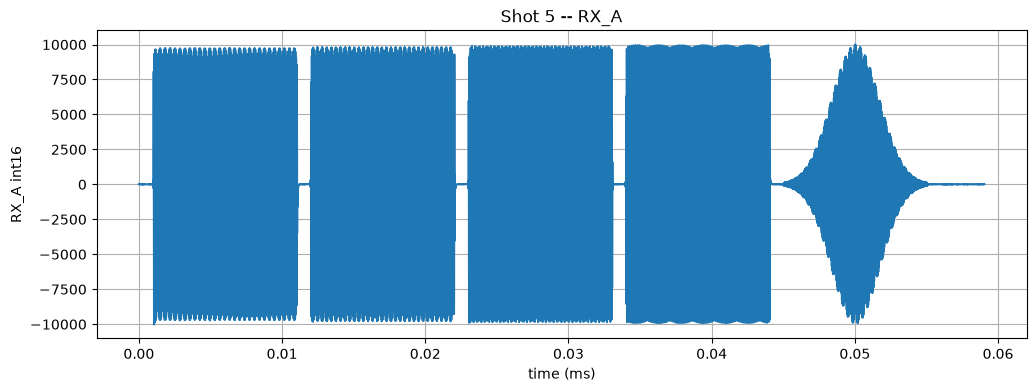

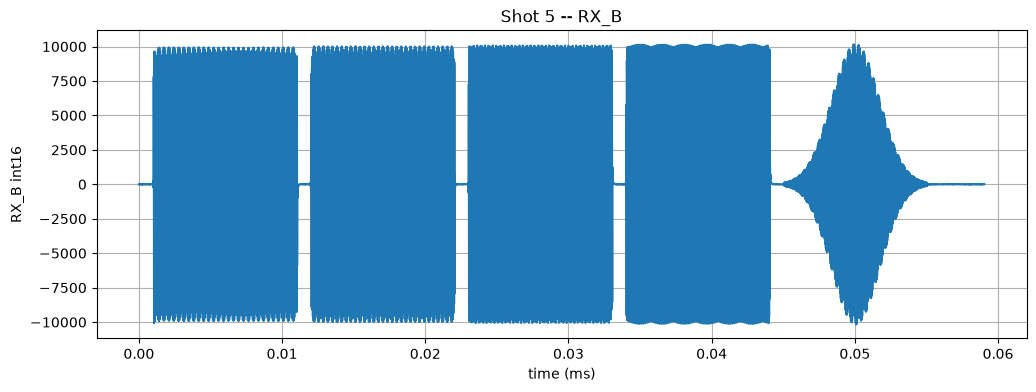

In [10]:
# ================= PLOTTING =================
import matplotlib.pyplot as plt

SHOT_TO_PLOT = 5
rx_a, rx_b = load_shot(SHOT_TO_PLOT)
fs = float(meta["fs_hz"])
t_a = np.arange(len(rx_a))/fs
t_b = np.arange(len(rx_b))/fs

plt.figure(figsize=(12,4)); plt.plot(t_a*1e3, rx_a); plt.xlabel("time (ms)"); plt.ylabel("RX_A int16"); plt.title(f"Shot {SHOT_TO_PLOT} -- RX_A"); plt.grid(True); plt.show()
plt.figure(figsize=(12,4)); plt.plot(t_b*1e3, rx_b); plt.xlabel("time (ms)"); plt.ylabel("RX_B int16"); plt.title(f"Shot {SHOT_TO_PLOT} -- RX_B"); plt.grid(True); plt.show()
